# Data Transformation for Wide&Deep Career Recommender
## Unified Dataset Creation from Three Sources

**Goal:** Transform AI Career, Career Paths, and Skill & Career datasets into a unified format for Wide&Deep model training

**Strategy:**
- Use `Recommended_Career` / `Recommended Career` / `Job profession` as the **category_id** (target)
- Extract skills from all three datasets
- Normalize education levels
- Create user profiles with psychometric scores (from Skills & Career dataset)
- Generate final training dataset with Wide & Deep features

---

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import json
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# Plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Paths
data_dir = Path('/workspace/data/raw')
output_dir = Path('/workspace/data/processed')
output_dir.mkdir(parents=True, exist_ok=True)

print("✓ Setup complete")
print(f"  Data directory: {data_dir}")
print(f"  Output directory: {output_dir}")

✓ Setup complete
  Data directory: /workspace/data/raw
  Output directory: /workspace/data/processed


---
## 2. Load Datasets

In [2]:
# Load all three datasets
print("Loading datasets...")

df_ai = pd.read_csv(data_dir / 'ai_career.csv')
print(f"  AI Career: {df_ai.shape[0]:,} rows × {df_ai.shape[1]} columns")

df_career = pd.read_csv(data_dir / 'career_paths.csv')
print(f"  Career Paths: {df_career.shape[0]:,} rows × {df_career.shape[1]} columns")

df_skill = pd.read_csv(data_dir / 'skill_career.csv')
print(f"  Skill & Career: {df_skill.shape[0]:,} rows × {df_skill.shape[1]} columns")

print(f"\nTotal records: {df_ai.shape[0] + df_career.shape[0] + df_skill.shape[0]:,}")

Loading datasets...
  AI Career: 200 rows × 8 columns
  Career Paths: 5,000 rows × 6 columns
  Skill & Career: 3,999 rows × 21 columns

Total records: 9,199


---
## 3. Build Unified Career Catalog (category_id)

Extract all unique careers from the three datasets to create our target classes.

In [3]:
# Extract careers from each dataset
careers_ai = df_ai['Recommended_Career'].dropna().unique()
careers_path = df_career['Recommended Career'].dropna().unique()
careers_skill = df_skill['Job profession'].dropna().unique()

print(f"Careers in AI dataset: {len(careers_ai)}")
print(f"Careers in Career Paths: {len(careers_path)}")
print(f"Careers in Skill & Career: {len(careers_skill)}")

# Combine and clean
all_careers = set()
all_careers.update([str(c).strip() for c in careers_ai])
all_careers.update([str(c).strip() for c in careers_path])
all_careers.update([str(c).strip() for c in careers_skill])

# Remove invalid entries
all_careers = {c for c in all_careers if c and c != 'nan'}

# Create catalog
career_catalog = pd.DataFrame({
    'category_id': range(1, len(all_careers) + 1),
    'career_name': sorted(list(all_careers))
})

print(f"\nTotal unique careers: {len(career_catalog)}")
print("\nFirst 10 careers:")
display(career_catalog.head(10))

# Save catalog
career_catalog.to_csv(output_dir / 'career_catalog.csv', index=False)
print(f"\n✓ Career catalog saved to {output_dir / 'career_catalog.csv'}")

Careers in AI dataset: 32
Careers in Career Paths: 12
Careers in Skill & Career: 72

Total unique careers: 110

First 10 careers:


,category_id,career_name
0,1,AI Researcher
1,2,AI Specialist
2,3,Actor / Actress
3,4,Actuary
4,5,Anthropologist
5,6,Archeologist
6,7,Artist
7,8,Astronomer
8,9,Athlete
9,10,Audiologist



✓ Career catalog saved to /workspace/data/processed/career_catalog.csv


---
## 4. Build Skills Catalog

Extract all skills from the three datasets.

In [4]:
# Extract skills
all_skills = set()

# From AI Career (Skills column is semicolon-separated)
if 'Skills' in df_ai.columns:
    for skills_str in df_ai['Skills'].dropna():
        skills = str(skills_str).split(';')
        all_skills.update([s.strip() for s in skills if s.strip()])

# From Career Paths (Skills column)
if 'Skills' in df_career.columns:
    for skill in df_career['Skills'].dropna():
        all_skills.add(str(skill).strip())

# From Skill & Career (Course column might contain skills)
# Also use the psychometric dimensions as "soft skills"
psychometric_skills = [
    'Linguistic', 'Musical', 'Bodily', 'Logical-Mathematical',
    'Spatial-Visualization', 'Interpersonal', 'Intrapersonal', 'Naturalist'
]
all_skills.update(psychometric_skills)

# Remove invalid
all_skills = {s for s in all_skills if s and s != 'nan' and len(s) > 1}

# Create catalog
skill_catalog = pd.DataFrame({
    'skill_id': range(1, len(all_skills) + 1),
    'skill_name': sorted(list(all_skills))
})

print(f"Total unique skills: {len(skill_catalog)}")
print("\nFirst 20 skills:")
display(skill_catalog.head(20))

# Save
skill_catalog.to_csv(output_dir / 'skill_catalog.csv', index=False)
print(f"\n✓ Skill catalog saved to {output_dir / 'skill_catalog.csv'}")

Total unique skills: 838

First 20 skills:


,skill_id,skill_name
0,1,.NET
1,2,AI
2,3,Accounting
3,4,"Accounting, Communication"
4,5,"Accounting, Communication, Counseling"
5,6,"Accounting, Communication, Data Analysis"
6,7,"Accounting, Communication, Financial Analysis"
7,8,"Accounting, Communication, MS Office"
8,9,"Accounting, Communication, Machine Learning"
9,10,"Accounting, Communication, Marketing"



✓ Skill catalog saved to /workspace/data/processed/skill_catalog.csv


---
## 5. Transform Dataset 1: AI Career

Create unified records from AI Career dataset.

In [5]:
def transform_ai_career(df, career_cat, skill_cat):
    """
    Transform AI Career dataset to unified format.
    
    Columns: CandidateID, Name, Age, Education, Skills, Interests, Recommended_Career, Recommendation_Score
    """
    records = []
    
    # Create career mapping
    career_map = dict(zip(career_cat['career_name'], career_cat['category_id']))
    skill_map = dict(zip(skill_cat['skill_name'], skill_cat['skill_id']))
    
    for idx, row in df.iterrows():
        # Career (target)
        career = str(row['Recommended_Career']).strip()
        if career not in career_map or career == 'nan':
            continue
        
        # Extract skills
        skills_str = str(row['Skills']) if pd.notna(row['Skills']) else ''
        skills_list = [s.strip() for s in skills_str.split(';') if s.strip()]
        skill_ids = [skill_map.get(s) for s in skills_list if s in skill_map]
        skill_ids = [s for s in skill_ids if s is not None]
        
        # Education level mapping
        edu_mapping = {
            "Bachelor's": 1,
            "Master's": 2,
            "PhD": 3
        }
        education_level = edu_mapping.get(row['Education'], 1)
        
        records.append({
            'user_id': f"ai_{row['CandidateID']}",
            'source_dataset': 'ai_career',
            'age': row['Age'] if pd.notna(row['Age']) else 22,
            'education_level': education_level,
            'skills': skill_ids,
            'num_skills': len(skill_ids),
            'recommended_career': career,
            'category_id': career_map[career],
            'recommendation_score': row['Recommendation_Score'] if pd.notna(row['Recommendation_Score']) else 0.5,
            # Psychometric (not available in this dataset - use defaults)
            'linguistic': 0.0,
            'musical': 0.0,
            'bodily': 0.0,
            'logical_mathematical': 0.0,
            'spatial_visualization': 0.0,
            'interpersonal': 0.0,
            'intrapersonal': 0.0,
            'naturalist': 0.0
        })
    
    return pd.DataFrame(records)

# Transform
df_ai_transformed = transform_ai_career(df_ai, career_catalog, skill_catalog)

print(f"AI Career transformed: {len(df_ai_transformed):,} records")
print(f"Average skills per user: {df_ai_transformed['num_skills'].mean():.1f}")
print(f"Unique careers: {df_ai_transformed['category_id'].nunique()}")

display(df_ai_transformed.head())

AI Career transformed: 200 records
Average skills per user: 3.0
Unique careers: 32


,user_id,source_dataset,age,education_level,skills,num_skills,recommended_career,category_id,recommendation_score,linguistic,musical,bodily,logical_mathematical,spatial_visualization,interpersonal,intrapersonal,naturalist
0,ai_1,ai_career,28,1,"[672, 256, 514]",3,Data Scientist,35,0.95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ai_2,ai_career,32,2,"[436, 830, 95]",3,Software Engineer,103,0.90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ai_3,ai_career,24,1,"[429, 833, 79]",3,UX Designer,107,0.88,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ai_4,ai_career,26,1,"[672, 342, 828]",3,AI Researcher,1,0.93,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ai_5,ai_career,30,2,"[670, 96, 83]",3,Project Manager,91,0.87,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---
## 6. Transform Dataset 2: Career Paths

Create unified records from Career Paths dataset.

In [6]:
def transform_career_paths(df, career_cat, skill_cat):
    """
    Transform Career Paths dataset.
    
    Columns: Education Level, Specialization, Skills, Certifications, CGPA/Percentage, Recommended Career
    """
    records = []
    
    career_map = dict(zip(career_cat['career_name'], career_cat['category_id']))
    skill_map = dict(zip(skill_cat['skill_name'], skill_cat['skill_id']))
    
    # Education level mapping
    edu_mapping = {
        'Matric': 0,
        'Intermediate': 0.5,
        "Bachelor's": 1,
        "Master's": 2,
        'PhD': 3
    }
    
    for idx, row in df.iterrows():
        # Career
        career = str(row['Recommended Career']).strip()
        if career not in career_map or career == 'nan':
            continue
        
        # Skills
        skill_name = str(row['Skills']).strip() if pd.notna(row['Skills']) else ''
        skill_ids = [skill_map.get(skill_name)] if skill_name in skill_map else []
        skill_ids = [s for s in skill_ids if s is not None]
        
        # Education
        edu_level = edu_mapping.get(row['Education Level'], 1)
        
        # CGPA/Percentage as a proxy for capability
        cgpa = row['CGPA/Percentage'] if pd.notna(row['CGPA/Percentage']) else 75
        
        records.append({
            'user_id': f"career_{idx}",
            'source_dataset': 'career_paths',
            'age': np.random.randint(18, 30),  # Estimated
            'education_level': edu_level,
            'skills': skill_ids,
            'num_skills': len(skill_ids),
            'recommended_career': career,
            'category_id': career_map[career],
            'recommendation_score': min(cgpa / 100, 1.0),  # Normalize CGPA as score
            # Psychometric - not available
            'linguistic': 0.0,
            'musical': 0.0,
            'bodily': 0.0,
            'logical_mathematical': 0.0,
            'spatial_visualization': 0.0,
            'interpersonal': 0.0,
            'intrapersonal': 0.0,
            'naturalist': 0.0,
            # Additional info
            'specialization': row['Specialization'] if pd.notna(row['Specialization']) else '',
            'cgpa': cgpa
        })
    
    return pd.DataFrame(records)

# Transform
df_career_transformed = transform_career_paths(df_career, career_catalog, skill_catalog)

print(f"Career Paths transformed: {len(df_career_transformed):,} records")
print(f"Average skills per user: {df_career_transformed['num_skills'].mean():.1f}")
print(f"Unique careers: {df_career_transformed['category_id'].nunique()}")

display(df_career_transformed.head())

Career Paths transformed: 5,000 records
Average skills per user: 1.0
Unique careers: 12


,user_id,source_dataset,age,education_level,skills,num_skills,recommended_career,category_id,recommendation_score,linguistic,musical,bodily,logical_mathematical,spatial_visualization,interpersonal,intrapersonal,naturalist,specialization,cgpa
0,career_0,career_paths,21,1.0,[216],1,Business Analyst,16,0.67,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Finance,67
1,career_1,career_paths,29,0.5,[39],1,Software Engineer,103,0.67,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Science,67
2,career_2,career_paths,27,2.0,[75],1,Financial Analyst,46,0.90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Business,90
3,career_3,career_paths,18,1.0,[96],1,Clerk,20,0.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Computer Science,75
4,career_4,career_paths,26,0.0,[256],1,Sales Assistant,98,0.83,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Business,83


---
## 7. Transform Dataset 3: Skill & Career

This dataset has psychometric scores - very valuable!

In [7]:
def transform_skill_career(df, career_cat, skill_cat):
    """
    Transform Skill & Career dataset.
    
    Columns: Sr.No., Course, Job profession, Student, 
             Linguistic, Musical, Bodily, Logical-Mathematical, Spatial-Visualization,
             Interpersonal, Intrapersonal, Naturalist, s/p, P1-P8
    """
    records = []
    
    career_map = dict(zip(career_cat['career_name'], career_cat['category_id']))
    skill_map = dict(zip(skill_cat['skill_name'], skill_cat['skill_id']))
    
    # Psychometric columns
    psycho_cols = [
        'Linguistic', 'Musical', 'Bodily', 'Logical - Mathematical',
        'Spatial-Visualization', 'Interpersonal', 'Intrapersonal', 'Naturalist'
    ]
    
    for idx, row in df.iterrows():
        # Career
        career = str(row['Job profession']).strip()
        # Clean newlines
        career = career.replace('\n', '').strip()
        
        if career not in career_map or career == 'nan':
            continue
        
        # Extract psychometric scores (normalize to 0-1)
        # These appear to be numeric scores
        def normalize_score(val, max_val=100):
            if pd.isna(val):
                return 0.0
            return float(val) / max_val
        
        linguistic = normalize_score(row.get('Linguistic', 0))
        musical = normalize_score(row.get('Musical', 0))
        bodily = normalize_score(row.get('Bodily', 0))
        logical_math = normalize_score(row.get('Logical - Mathematical', 0))
        spatial = normalize_score(row.get('Spatial-Visualization', 0))
        interpersonal = normalize_score(row.get('Interpersonal', 0))
        intrapersonal = normalize_score(row.get('Intrapersonal', 0))
        naturalist = normalize_score(row.get('Naturalist', 0))
        
        # Skills - map psychometric scores to skill IDs
        skill_ids = []
        if linguistic > 0.5:
            skill_ids.append(skill_map.get('Linguistic'))
        if musical > 0.5:
            skill_ids.append(skill_map.get('Musical'))
        if bodily > 0.5:
            skill_ids.append(skill_map.get('Bodily'))
        if logical_math > 0.5:
            skill_ids.append(skill_map.get('Logical-Mathematical'))
        if spatial > 0.5:
            skill_ids.append(skill_map.get('Spatial-Visualization'))
        if interpersonal > 0.5:
            skill_ids.append(skill_map.get('Interpersonal'))
        if intrapersonal > 0.5:
            skill_ids.append(skill_map.get('Intrapersonal'))
        if naturalist > 0.5:
            skill_ids.append(skill_map.get('Naturalist'))
        
        skill_ids = [s for s in skill_ids if s is not None]
        
        records.append({
            'user_id': f"skill_{idx}",
            'source_dataset': 'skill_career',
            'age': np.random.randint(18, 25),  # Estimated students
            'education_level': 1,  # Assume Bachelor's level
            'skills': skill_ids,
            'num_skills': len(skill_ids),
            'recommended_career': career,
            'category_id': career_map[career],
            'recommendation_score': 0.7,  # Default moderate confidence
            # Psychometric scores (key feature!)
            'linguistic': linguistic,
            'musical': musical,
            'bodily': bodily,
            'logical_mathematical': logical_math,
            'spatial_visualization': spatial,
            'interpersonal': interpersonal,
            'intrapersonal': intrapersonal,
            'naturalist': naturalist
        })
    
    return pd.DataFrame(records)

# Transform
df_skill_transformed = transform_skill_career(df_skill, career_catalog, skill_catalog)

print(f"Skill & Career transformed: {len(df_skill_transformed):,} records")
print(f"Average skills per user: {df_skill_transformed['num_skills'].mean():.1f}")
print(f"Unique careers: {df_skill_transformed['category_id'].nunique()}")
print(f"\nPsychometric coverage: {(df_skill_transformed['linguistic'] > 0).sum():,} records have scores")

display(df_skill_transformed.head())

Skill & Career transformed: 3,600 records
Average skills per user: 0.0
Unique careers: 72

Psychometric coverage: 3,600 records have scores


,user_id,source_dataset,age,education_level,skills,num_skills,recommended_career,category_id,recommendation_score,linguistic,musical,bodily,logical_mathematical,spatial_visualization,interpersonal,intrapersonal,naturalist
0,skill_0,skill_career,18,1,[],0,Astronomer,8,0.7,0.11,0.05,0.12,0.16,0.17,0.11,0.18,0.19
1,skill_1,skill_career,18,1,[],0,Astronomer,8,0.7,0.12,0.06,0.12,0.16,0.16,0.11,0.18,0.19
2,skill_2,skill_career,20,1,[],0,Astronomer,8,0.7,0.13,0.07,0.12,0.16,0.15,0.11,0.18,0.19
3,skill_3,skill_career,20,1,[],0,Astronomer,8,0.7,0.14,0.08,0.12,0.16,0.19,0.11,0.18,0.19
4,skill_4,skill_career,24,1,[],0,Astronomer,8,0.7,0.13,0.09,0.12,0.16,0.20,0.11,0.19,0.19


---
## 8. Combine All Datasets

Create the unified master dataset.

In [8]:
# Combine all three
df_unified = pd.concat([
    df_ai_transformed,
    df_career_transformed,
    df_skill_transformed
], ignore_index=True)

print(f"Total unified records: {len(df_unified):,}")
print(f"Unique users: {df_unified['user_id'].nunique():,}")
print(f"Unique careers (targets): {df_unified['category_id'].nunique()}")

print("\nDataset distribution:")
print(df_unified['source_dataset'].value_counts())

print("\nCareer distribution (top 10):")
print(df_unified['recommended_career'].value_counts().head(10))

# Data quality check
print("\n" + "="*60)
print("DATA QUALITY")
print("="*60)
print(f"Missing values:")
print(df_unified.isnull().sum())

display(df_unified.head(10))

Total unified records: 8,800
Unique users: 8,800
Unique careers (targets): 110

Dataset distribution:
source_dataset
career_paths    5000
skill_career    3600
ai_career        200
Name: count, dtype: int64

Career distribution (top 10):
recommended_career
Business Analyst       452
Clerk                  432
Marketing Executive    432
ML Engineer            429
Research Scientist     425
Software Engineer      421
Financial Analyst      421
School Counselor       417
Data Entry Operator    413
Junior Accountant      413
Name: count, dtype: int64

DATA QUALITY
Missing values:
user_id                     0
source_dataset              0
age                         0
education_level             0
skills                      0
num_skills                  0
recommended_career          0
category_id                 0
recommendation_score        0
linguistic                  0
musical                     0
bodily                      0
logical_mathematical        0
spatial_visualization       

,user_id,source_dataset,age,education_level,skills,num_skills,recommended_career,category_id,recommendation_score,linguistic,musical,bodily,logical_mathematical,spatial_visualization,interpersonal,intrapersonal,naturalist,specialization,cgpa
0,ai_1,ai_career,28,1.0,"[672, 256, 514]",3,Data Scientist,35,0.95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,ai_2,ai_career,32,2.0,"[436, 830, 95]",3,Software Engineer,103,0.90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,ai_3,ai_career,24,1.0,"[429, 833, 79]",3,UX Designer,107,0.88,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
3,ai_4,ai_career,26,1.0,"[672, 342, 828]",3,AI Researcher,1,0.93,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
4,ai_5,ai_career,30,2.0,"[670, 96, 83]",3,Project Manager,91,0.87,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
5,ai_6,ai_career,27,1.0,"[92, 348, 435]",3,Embedded Systems Engineer,42,0.91,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
6,ai_7,ai_career,35,2.0,"[754, 341, 346]",3,Data Analyst,32,0.89,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
7,ai_8,ai_career,29,1.0,"[177, 753, 823]",3,Digital Marketer,39,0.86,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
8,ai_9,ai_career,31,1.0,"[672, 665, 514]",3,NLP Engineer,75,0.92,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
9,ai_10,ai_career,33,2.0,"[350, 349, 347]",3,Financial Analyst,46,0.90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


---
## 9. Feature Engineering for Wide&Deep Model

Create features suitable for the Wide&Deep architecture.

In [9]:
def create_wide_deep_features(df):
    """
    Create Wide (categorical) and Deep (continuous/embedding) features.
    """
    df_features = df.copy()
    
    # ===== WIDE FEATURES (Categorical) =====
    # These will be one-hot encoded or embedded
    
    # Education level buckets
    df_features['edu_bucket'] = pd.cut(
        df_features['education_level'],
        bins=[-0.1, 0.7, 1.5, 2.5, 3.5],
        labels=['high_school', 'bachelors', 'masters', 'phd']
    )
    
    # Age buckets
    df_features['age_bucket'] = pd.cut(
        df_features['age'],
        bins=[0, 20, 25, 30, 100],
        labels=['18-20', '21-25', '26-30', '30+']
    )
    
    # Skill count buckets
    df_features['skill_bucket'] = pd.cut(
        df_features['num_skills'],
        bins=[-1, 0, 2, 5, 100],
        labels=['no_skills', 'few_skills', 'some_skills', 'many_skills']
    )
    
    # ===== DEEP FEATURES (Continuous) =====
    
    # Normalize continuous features
    deep_features = [
        'age', 'education_level', 'num_skills', 'recommendation_score',
        'linguistic', 'musical', 'bodily', 'logical_mathematical',
        'spatial_visualization', 'interpersonal', 'intrapersonal', 'naturalist'
    ]
    
    # Create average psychometric score
    psycho_cols = [
        'linguistic', 'musical', 'bodily', 'logical_mathematical',
        'spatial_visualization', 'interpersonal', 'intrapersonal', 'naturalist'
    ]
    df_features['avg_psychometric'] = df_features[psycho_cols].mean(axis=1)
    
    # Dominant psychometric dimension
    df_features['dominant_trait'] = df_features[psycho_cols].idxmax(axis=1)
    
    return df_features

# Create features
df_features = create_wide_deep_features(df_unified)

print("Features created!")
print(f"\nWide features (categorical):")
print(f"  - edu_bucket: {df_features['edu_bucket'].nunique()} categories")
print(f"  - age_bucket: {df_features['age_bucket'].nunique()} categories")
print(f"  - skill_bucket: {df_features['skill_bucket'].nunique()} categories")
print(f"  - dominant_trait: {df_features['dominant_trait'].nunique()} categories")

print(f"\nDeep features (continuous): 13 features")

display(df_features[['user_id', 'edu_bucket', 'age_bucket', 'skill_bucket', 
                      'avg_psychometric', 'dominant_trait', 'category_id']].head(10))

Features created!

Wide features (categorical):
  - edu_bucket: 4 categories
  - age_bucket: 4 categories
  - skill_bucket: 3 categories
  - dominant_trait: 8 categories

Deep features (continuous): 13 features


,user_id,edu_bucket,age_bucket,skill_bucket,avg_psychometric,dominant_trait,category_id
0,ai_1,bachelors,26-30,some_skills,0.0,linguistic,35
1,ai_2,masters,30+,some_skills,0.0,linguistic,103
2,ai_3,bachelors,21-25,some_skills,0.0,linguistic,107
3,ai_4,bachelors,26-30,some_skills,0.0,linguistic,1
4,ai_5,masters,26-30,some_skills,0.0,linguistic,91
5,ai_6,bachelors,26-30,some_skills,0.0,linguistic,42
6,ai_7,masters,30+,some_skills,0.0,linguistic,32
7,ai_8,bachelors,26-30,some_skills,0.0,linguistic,39
8,ai_9,bachelors,30+,some_skills,0.0,linguistic,75
9,ai_10,masters,30+,some_skills,0.0,linguistic,46


---
## 10. Encode Categorical Variables

In [10]:
# Create label encoders for categorical variables
encoders = {}

categorical_cols = ['edu_bucket', 'age_bucket', 'skill_bucket', 'dominant_trait', 'source_dataset']

for col in categorical_cols:
    le = LabelEncoder()
    df_features[f'{col}_encoded'] = le.fit_transform(df_features[col].astype(str))
    encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} classes")

# Target encoding (category_id is already numeric)
print(f"\nTarget (category_id): {df_features['category_id'].nunique()} classes")
print(f"Target range: {df_features['category_id'].min()} - {df_features['category_id'].max()}")

Encoded edu_bucket: 4 classes
Encoded age_bucket: 4 classes
Encoded skill_bucket: 3 classes
Encoded dominant_trait: 8 classes
Encoded source_dataset: 3 classes

Target (category_id): 110 classes
Target range: 1 - 110


---
## 11. Create Skill Vector (Multi-hot Encoding)

Convert skill lists to multi-hot encoded vectors.

In [11]:
# Create multi-hot skill vectors
num_skills = len(skill_catalog)

def skills_to_vector(skill_ids, total_skills):
    """
    Convert list of skill IDs to binary vector.
    """
    vector = np.zeros(total_skills, dtype=np.float32)
    if isinstance(skill_ids, list):
        for skill_id in skill_ids:
            if skill_id and 1 <= skill_id <= total_skills:
                vector[skill_id - 1] = 1.0
    return vector

# Apply to all rows
print(f"Creating skill vectors of dimension {num_skills}...")
skill_vectors = np.array([
    skills_to_vector(row['skills'], num_skills) 
    for _, row in df_features.iterrows()
])

print(f"Skill vector shape: {skill_vectors.shape}")
print(f"Sparsity: {100 * (1 - skill_vectors.mean()):.2f}%")
print(f"Average skills per user: {skill_vectors.sum(axis=1).mean():.2f}")

Creating skill vectors of dimension 838...
Skill vector shape: (8800, 838)
Sparsity: 99.92%
Average skills per user: 0.64


---
## 12. Create Final Training Dataset

In [12]:
# Assemble final feature matrix

# Wide features (categorical indices)
wide_features = df_features[[
    'edu_bucket_encoded',
    'age_bucket_encoded', 
    'skill_bucket_encoded',
    'dominant_trait_encoded',
    'source_dataset_encoded'
]].values

# Deep features (continuous)
deep_continuous = df_features[[
    'age', 'education_level', 'num_skills', 'recommendation_score',
    'linguistic', 'musical', 'bodily', 'logical_mathematical',
    'spatial_visualization', 'interpersonal', 'intrapersonal', 'naturalist',
    'avg_psychometric'
]].values

# Combine deep features: continuous + skill vector
deep_features = np.hstack([deep_continuous, skill_vectors])

# Labels
labels = df_features['category_id'].values - 1  # Zero-indexed for model

print("Final Dataset Summary:")
print("="*60)
print(f"Total samples: {len(labels):,}")
print(f"Wide features shape: {wide_features.shape}")
print(f"Deep features shape: {deep_features.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Number of classes: {len(np.unique(labels))}")

# Class distribution
unique, counts = np.unique(labels, return_counts=True)
print(f"\nClass distribution:")
print(f"  Min samples per class: {counts.min()}")
print(f"  Max samples per class: {counts.max()}")
print(f"  Avg samples per class: {counts.mean():.1f}")

Final Dataset Summary:
Total samples: 8,800
Wide features shape: (8800, 5)
Deep features shape: (8800, 851)
Labels shape: (8800,)
Number of classes: 110

Class distribution:
  Min samples per class: 3
  Max samples per class: 452
  Avg samples per class: 80.0


---
## 13. Train/Test Split

In [13]:
# Split data
(
    wide_train, wide_test,
    deep_train, deep_test,
    y_train, y_test
) = train_test_split(
    wide_features, deep_features, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels  # Maintain class distribution
)

print("Train/Test Split:")
print("="*60)
print(f"Training samples: {len(y_train):,}")
print(f"Test samples: {len(y_test):,}")
print(f"\nTraining set:")
print(f"  Wide: {wide_train.shape}")
print(f"  Deep: {deep_train.shape}")
print(f"  Labels: {y_train.shape}")
print(f"\nTest set:")
print(f"  Wide: {wide_test.shape}")
print(f"  Deep: {deep_test.shape}")
print(f"  Labels: {y_test.shape}")

Train/Test Split:
Training samples: 7,040
Test samples: 1,760

Training set:
  Wide: (7040, 5)
  Deep: (7040, 851)
  Labels: (7040,)

Test set:
  Wide: (1760, 5)
  Deep: (1760, 851)
  Labels: (1760,)


---
## 14. Save Processed Data

In [14]:
# Save everything
print("Saving processed data...\n")

# 1. Unified DataFrame
df_features.to_csv(output_dir / 'unified_dataset.csv', index=False)
print(f"✓ Unified dataset: {output_dir / 'unified_dataset.csv'}")

# 2. NumPy arrays for training
np.save(output_dir / 'wide_train.npy', wide_train)
np.save(output_dir / 'wide_test.npy', wide_test)
np.save(output_dir / 'deep_train.npy', deep_train)
np.save(output_dir / 'deep_test.npy', deep_test)
np.save(output_dir / 'y_train.npy', y_train)
np.save(output_dir / 'y_test.npy', y_test)
print(f"✓ NumPy arrays saved")

# 3. Skill vectors
np.save(output_dir / 'skill_vectors.npy', skill_vectors)
print(f"✓ Skill vectors saved")

# 4. Encoders
import pickle
with open(output_dir / 'label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)
print(f"✓ Label encoders saved")

# 5. Metadata
metadata = {
    'total_samples': int(len(df_features)),
    'train_samples': int(len(y_train)),
    'test_samples': int(len(y_test)),
    'num_classes': int(len(np.unique(labels))),
    'num_skills': int(num_skills),
    'wide_feature_dims': {
        'edu_bucket': int(df_features['edu_bucket_encoded'].max() + 1),
        'age_bucket': int(df_features['age_bucket_encoded'].max() + 1),
        'skill_bucket': int(df_features['skill_bucket_encoded'].max() + 1),
        'dominant_trait': int(df_features['dominant_trait_encoded'].max() + 1),
        'source_dataset': int(df_features['source_dataset_encoded'].max() + 1)
    },
    'deep_feature_dim': int(deep_features.shape[1]),
    'continuous_features': 13,
    'skill_vector_dim': int(num_skills),
    'feature_names': {
        'wide': ['edu_bucket', 'age_bucket', 'skill_bucket', 'dominant_trait', 'source_dataset'],
        'deep_continuous': [
            'age', 'education_level', 'num_skills', 'recommendation_score',
            'linguistic', 'musical', 'bodily', 'logical_mathematical',
            'spatial_visualization', 'interpersonal', 'intrapersonal', 'naturalist',
            'avg_psychometric'
        ],
        'deep_skills': f'skill_vector_{num_skills}d'
    }
}

with open(output_dir / 'dataset_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadata saved")

print("\n" + "="*60)
print("ALL DATA SAVED SUCCESSFULLY!")
print("="*60)
print(f"\nOutput directory: {output_dir}")
print("\nFiles created:")
for file in sorted(output_dir.glob('*')):
    size_mb = file.stat().st_size / (1024 * 1024)
    print(f"  {file.name:30s} ({size_mb:6.2f} MB)")

Saving processed data...

✓ Unified dataset: /workspace/data/processed/unified_dataset.csv
✓ NumPy arrays saved
✓ Skill vectors saved
✓ Label encoders saved
✓ Metadata saved

ALL DATA SAVED SUCCESSFULLY!

Output directory: /workspace/data/processed

Files created:
  career_catalog.csv             (  0.00 MB)
  dataset_metadata.json          (  0.00 MB)
  deep_test.npy                  ( 11.43 MB)
  deep_train.npy                 ( 45.71 MB)
  label_encoders.pkl             (  0.00 MB)
  skill_catalog.csv              (  0.03 MB)
  skill_vectors.npy              ( 28.13 MB)
  unified_dataset.csv            (  1.36 MB)
  wide_test.npy                  (  0.07 MB)
  wide_train.npy                 (  0.27 MB)
  y_test.npy                     (  0.01 MB)
  y_train.npy                    (  0.05 MB)


---
## 15. Data Summary & Visualizations

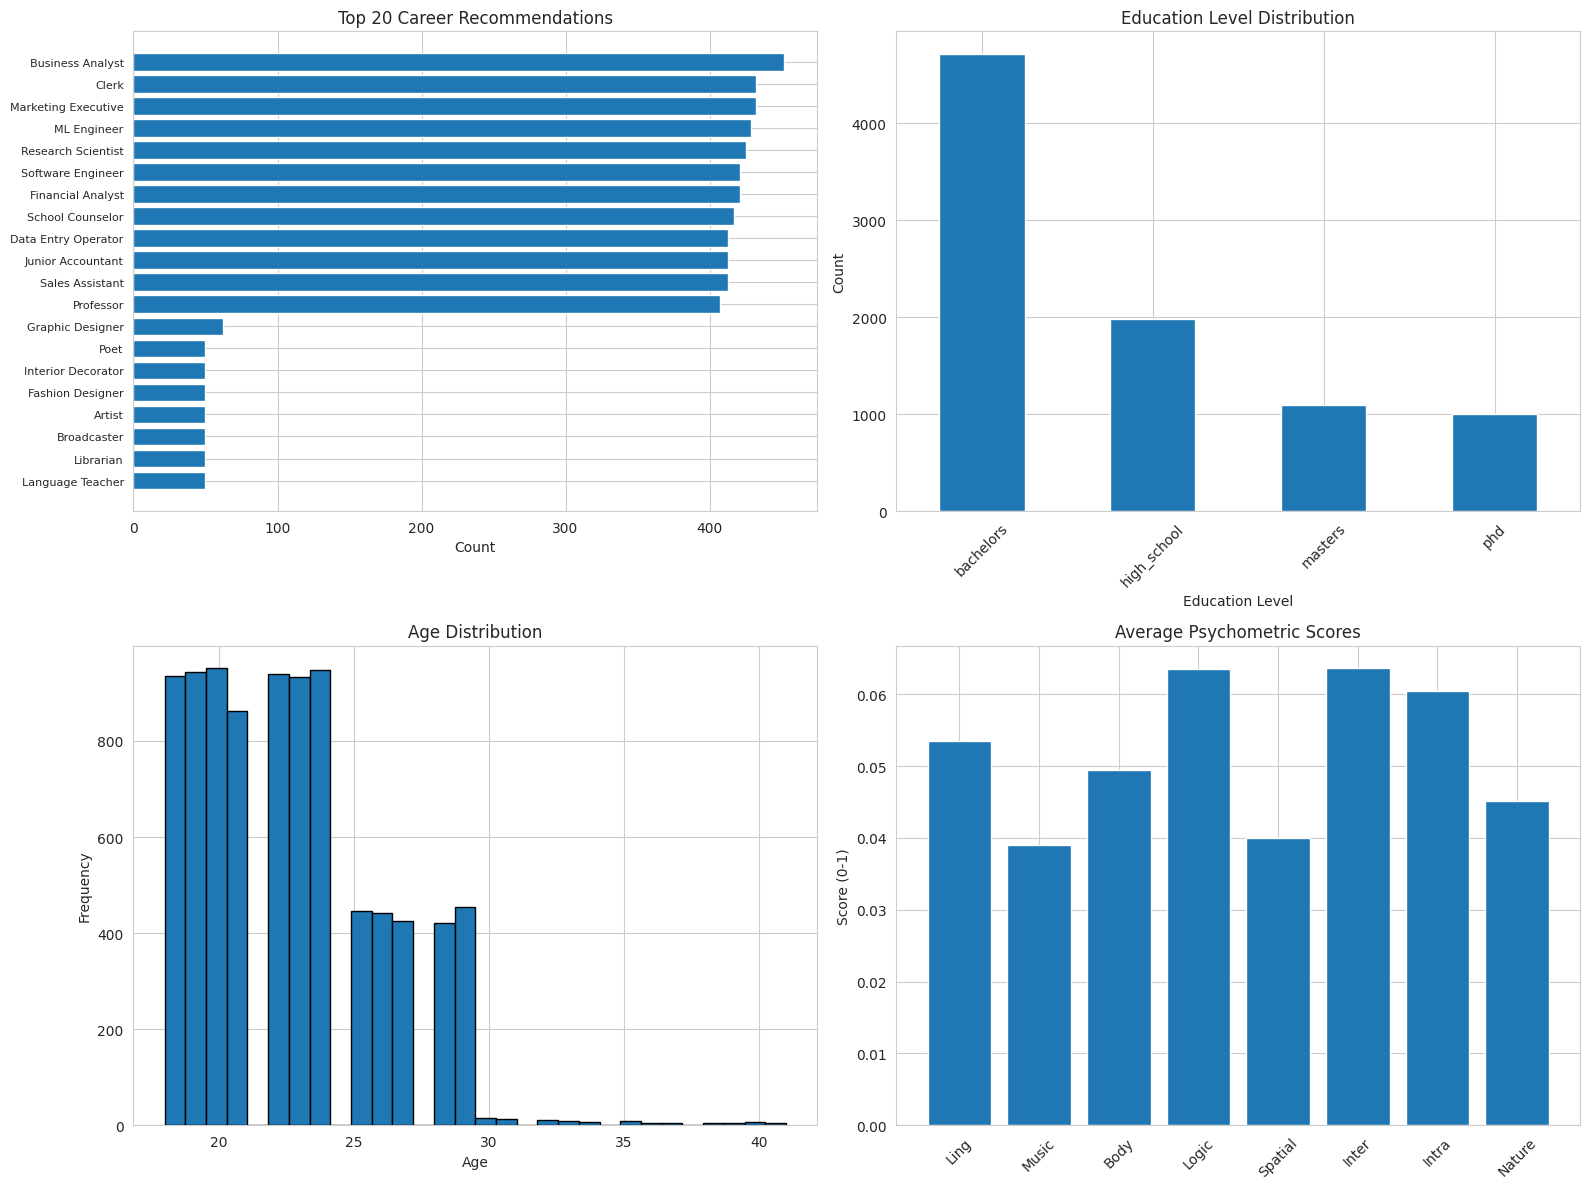

✓ Visualizations saved


In [15]:
# Visualize class distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Career distribution
career_counts = df_features['recommended_career'].value_counts().head(20)
axes[0, 0].barh(range(len(career_counts)), career_counts.values)
axes[0, 0].set_yticks(range(len(career_counts)))
axes[0, 0].set_yticklabels(career_counts.index, fontsize=8)
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_title('Top 20 Career Recommendations')
axes[0, 0].invert_yaxis()

# 2. Education distribution
df_features['edu_bucket'].value_counts().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Education Level Distribution')
axes[0, 1].set_xlabel('Education Level')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Age distribution
df_features['age'].hist(bins=30, ax=axes[1, 0], edgecolor='black')
axes[1, 0].set_title('Age Distribution')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Frequency')

# 4. Psychometric scores
psycho_means = df_features[[
    'linguistic', 'musical', 'bodily', 'logical_mathematical',
    'spatial_visualization', 'interpersonal', 'intrapersonal', 'naturalist'
]].mean()
axes[1, 1].bar(range(len(psycho_means)), psycho_means.values)
axes[1, 1].set_xticks(range(len(psycho_means)))
axes[1, 1].set_xticklabels([
    'Ling', 'Music', 'Body', 'Logic', 'Spatial', 'Inter', 'Intra', 'Nature'
], rotation=45)
axes[1, 1].set_title('Average Psychometric Scores')
axes[1, 1].set_ylabel('Score (0-1)')

plt.tight_layout()
plt.savefig(output_dir / 'data_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualizations saved")

---
## Summary

### What We Created:

1. **Unified Dataset** - Combined 3 sources into single format
2. **Career Catalog** - category_id mapping for all careers
3. **Skill Catalog** - Comprehensive skill database
4. **Wide Features** - 5 categorical features for memorization
5. **Deep Features** - 13 continuous + skill vector for generalization
6. **Train/Test Split** - 80/20 stratified split

### Ready for Model Training!

Next steps:
1. Build Wide&Deep model architecture
2. Train on this dataset
3. Evaluate performance
4. Deploy for recommendations

---